# K-En Yakın Komşu (K-Nearest Neighbors / KNN) Algoritması

**Veri Seti:** `glass.data` — Glass Identification (UCI), 214 örnek, 6 sınıflı (çok sınıflı) küçük bir veri seti.

**Amaç:** Camın kimyasal bileşimine (RI, Na, Mg, Al, Si, K, Ca, Ba, Fe) bakarak **cam tipini (Type)** sınıflandırmak.

## KNN Teorisi

**K-En Yakın Komşu**, "parametrik olmayan" (non-parametric), tembel öğrenme (lazy learning) yapan basit ama etkili bir sınıflandırma algoritmasıdır.

### Temel Fikir
KNN, eğitim aşamasında herhangi bir model/katsayı öğrenmez; sadece tüm eğitim verisini hafızasında tutar ("tembel öğrenme"). Yeni bir örnek geldiğinde:
1. Bu örnek ile eğitim setindeki **tüm örnekler arasındaki mesafeyi** hesaplar.
2. En yakın **k** komşuyu bulur.
3. Bu k komşunun **çoğunluk sınıfını** yeni örneğe atar (sınıflandırma) ya da ortalamasını alır (regresyon).

### Mesafe Ölçütleri
En yaygın kullanılan mesafe ölçütü **Öklid (Euclidean) mesafesidir**:

$$d(x, x') = \sqrt{\sum_{i=1}^{n}(x_i - x'_i)^2}$$

Diğer seçenekler: Manhattan mesafesi ($\sum|x_i - x'_i|$), Minkowski mesafesi (genel form).

### k Değerinin Önemi
- **Küçük k** (örn. k=1): Modelin varyansı yüksektir, gürültüye (outlier'lara) karşı hassastır → overfitting riski.
- **Büyük k**: Model daha "yumuşar", ama çok büyük k karar sınırını aşırı basitleştirip underfitting'e yol açabilir.
- Doğru k değeri genellikle **çapraz doğrulama (cross-validation)** ile bulunur.

### Neden Ölçeklendirme Şart?
KNN mesafeye dayalı bir algoritma olduğundan, farklı ölçeklerdeki öznitelikler (örn. biri 0-1 arası, diğeri 0-1000 arası) mesafe hesabını yanıltır. Bu yüzden **StandardScaler** ile ölçeklendirme KNN için kritik bir adımdır — tıpkı SVM'de olduğu gibi.

### Bu Çalışmada Ele Alınan Problem
**Glass Identification** veri seti, adli bilim (forensics) alanında bir suç mahallinde bulunan cam parçasının hangi tür cama ait olduğunu belirlemek için kullanılır. Veri seti **küçük (214 örnek)** ve **çok sınıflıdır (6 sınıf)**; bazı sınıflar çok az örneğe sahiptir. Bu, KNN'in küçük ve dengesiz çok sınıflı verilerde nasıl davrandığını gözlemlemek için iyi bir örnektir.

## 1. Gerekli Kütüphaneler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Veriyi Yükleme ve Keşfetme

In [2]:
col_names = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
df = pd.read_csv("glass.data", names=col_names)
df = df.drop(columns=["Id"])

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSütun isimleri: {', '.join(df.columns.tolist())}")
print(f"\nSınıf dağılımı (Type):")
print(df["Type"].value_counts().sort_index())
print(f"\nİlk 5 satır:")
display(df.head())
print(f"\nEksik değer sayısı: {df.isnull().sum().sum()}")

Veri seti boyutu: 214 satır, 10 sütun

Sütun isimleri: RI, Na, Mg, Al, Si, K, Ca, Ba, Fe, Type

Sınıf dağılımı (Type):
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

İlk 5 satır:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1



Eksik değer sayısı: 0


**Not — Küçük ve Dengesiz Çok Sınıflı Veri:** Bazı cam tipleri (örn. Type 6 - tableware) çok az örnekle temsil edilmektedir. Bu durum, test setinde bu sınıflardan yeterince örnek kalmamasına yol açabilir; bu yüzden `train_test_split` içinde `stratify` parametresini kullanacağız.

In [3]:
print("Sayısal değişkenlerin istatistikleri:")
print(df.describe().to_string())

Sayısal değişkenlerin istatistikleri:
               RI          Na          Mg          Al          Si           K          Ca          Ba          Fe        Type
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056    8.956963    0.175047    0.057009    2.780374
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192    1.423153    0.497219    0.097439    2.103739
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000    5.430000    0.000000    0.000000    1.000000
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500    8.240000    0.000000    0.000000    1.000000
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000    8.600000    0.000000    0.000000    2.000000
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   

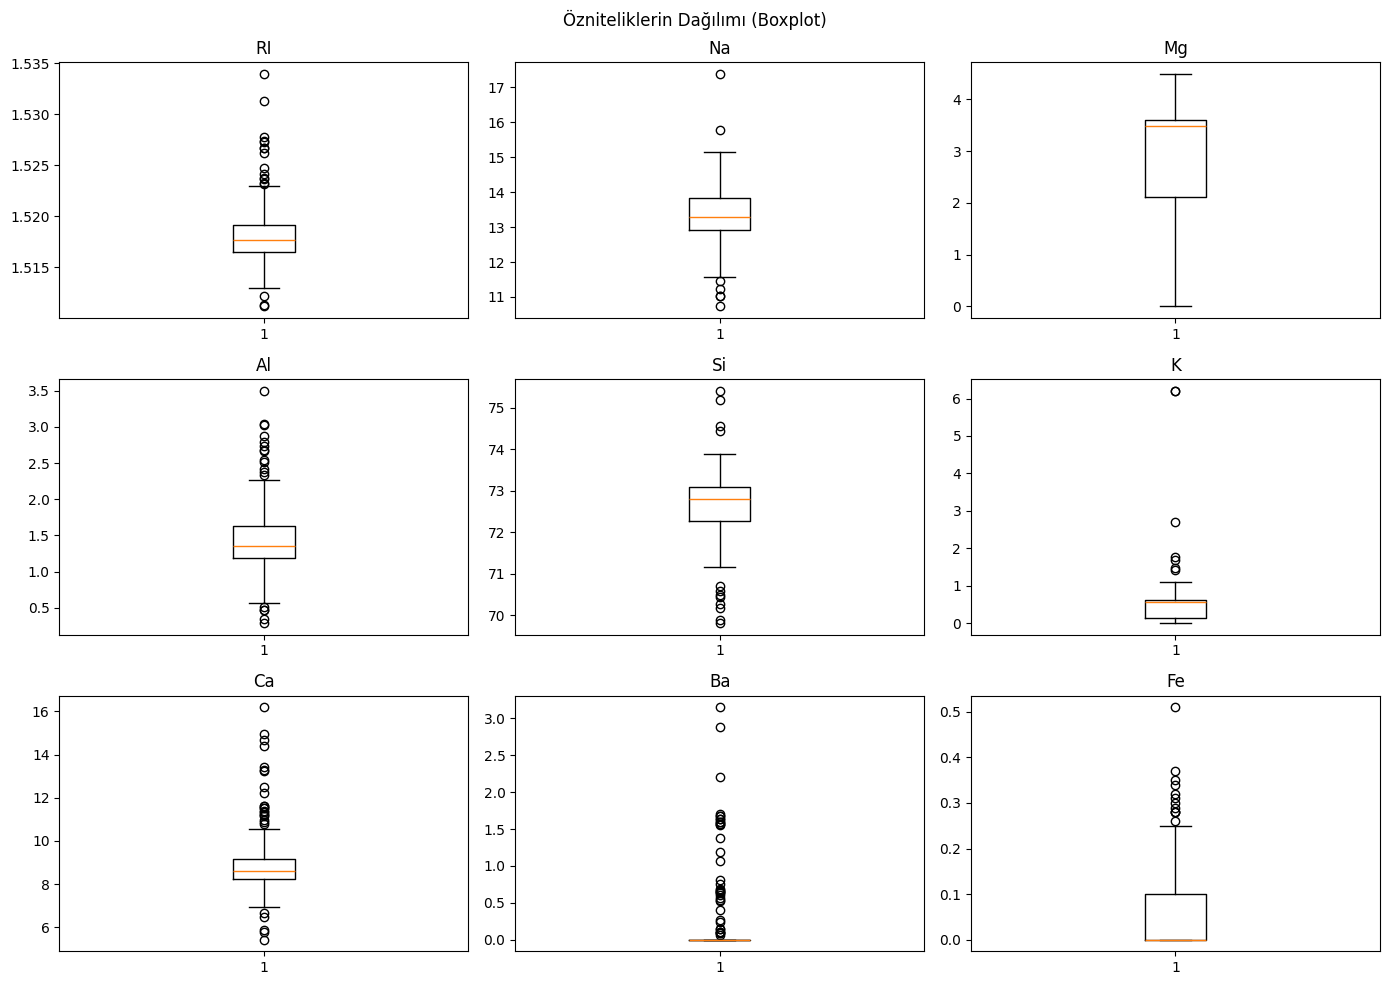

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
feature_cols = [c for c in df.columns if c != "Type"]
for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    ax.boxplot(df[col])
    ax.set_title(col)
for j in range(len(feature_cols), 9):
    axes[j // 3, j % 3].axis("off")
plt.suptitle("Özniteliklerin Dağılımı (Boxplot)")
plt.tight_layout()
plt.show()

## 3. Özellik ve Hedef Ayırma

In [5]:
X = df.drop("Type", axis=1)
y = df["Type"]

print(f"Özellik matrisi (X): {X.shape}")
print(f"Hedef vektör (y):   {y.shape}")
print(f"\nÖzellikler: {X.columns.tolist()}")
print(f"Sınıflar: {sorted(y.unique())}")

Özellik matrisi (X): (214, 9)
Hedef vektör (y):   (214,)

Özellikler: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
Sınıflar: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]


## 4. Eğitim/Test Ayrımı

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti:   {X_test.shape[0]} örnek")
print(f"\nEğitim seti sınıf dağılımı:\n{y_train.value_counts().sort_index()}")
print(f"\nTest seti sınıf dağılımı:\n{y_test.value_counts().sort_index()}")

Eğitim seti: 171 örnek
Test seti:   43 örnek

Eğitim seti sınıf dağılımı:
Type
1    56
2    61
3    14
5    10
6     7
7    23
Name: count, dtype: int64

Test seti sınıf dağılımı:
Type
1    14
2    15
3     3
5     3
6     2
7     6
Name: count, dtype: int64


## 5. Özellik Ölçeklendirme (Standardizasyon)

KNN mesafe tabanlı bir algoritma olduğu için özelliklerin aynı ölçekte olması **zorunludur** — aksi halde `Si` gibi büyük ölçekli öznitelikler mesafe hesabına haksız şekilde hakim olur.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Özellikler standardize edildi (mean=0, std=1)")
print(f"\nEğitim seti ilk satır (ölçeklenmiş):")
print(np.round(X_train_scaled[0], 3))

Özellikler standardize edildi (mean=0, std=1)

Eğitim seti ilk satır (ölçeklenmiş):
[-0.643 -1.706 -1.941 -0.501  3.215  3.99  -0.02  -0.345 -0.619]


## 6. Sıfırdan KNN Algoritması

KNN'in mantığını daha iyi anlamak için, önce kütüphane kullanmadan basit bir KNN sınıflandırıcı yazalım.

In [8]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

class KNNScratch:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x) for x in X])

    def _predict_one(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

In [9]:
knn_scratch = KNNScratch(k=5)
knn_scratch.fit(X_train_scaled, y_train.values)
y_pred_scratch = knn_scratch.predict(X_test_scaled)
accuracy_scratch = (y_pred_scratch == y_test.values).mean()

print(f"Sıfırdan yazdığımız KNN (k=5) test doğruluğu: {accuracy_scratch:.4f}")

Sıfırdan yazdığımız KNN (k=5) test doğruluğu: 0.6977


## 7. `scikit-learn` ile Karşılaştırma

Sıfırdan yazdığımız algoritmanın doğru çalıştığını, aynı k değerine sahip `scikit-learn` modeliyle karşılaştırarak doğrulayalım.

In [10]:
knn_sklearn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_sklearn.fit(X_train_scaled, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test_scaled)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Sıfırdan yazdığımız KNN doğruluğu : {accuracy_scratch:.4f}")
print(f"scikit-learn KNN doğruluğu        : {accuracy_sklearn:.4f}")

Sıfırdan yazdığımız KNN doğruluğu : 0.6977
scikit-learn KNN doğruluğu        : 0.7209


## 8. En İyi k Değerini Bulmak

Farklı k değerleri için doğruluğu (hem eğitim hem test) inceleyip en uygun k'yı belirleyelim ("dirsek yöntemi" - elbow method).

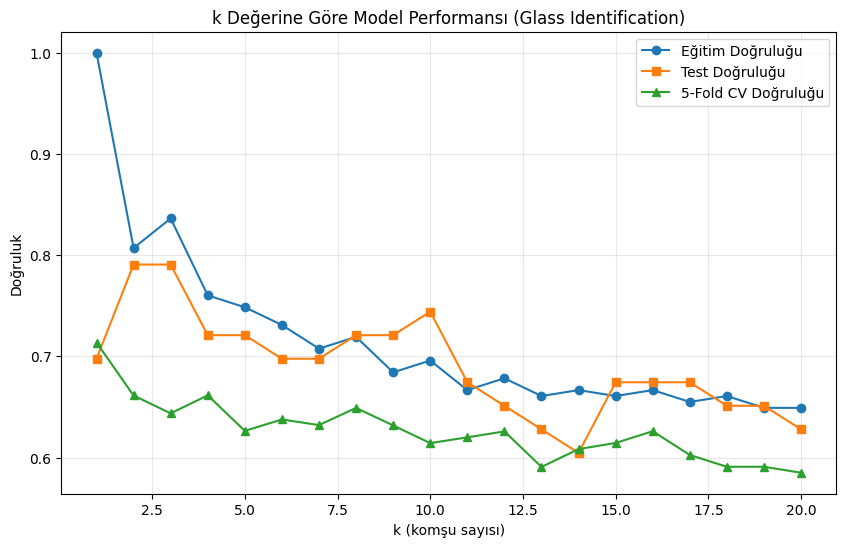


Cross-validation'a göre en iyi k: 1


In [11]:
k_values = range(1, 21)
train_accs = []
test_accs = []
cv_accs = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accs.append(knn.score(X_train_scaled, y_train))
    test_accs.append(knn.score(X_test_scaled, y_test))
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_accs.append(cv_scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accs, marker="o", label="Eğitim Doğruluğu")
plt.plot(k_values, test_accs, marker="s", label="Test Doğruluğu")
plt.plot(k_values, cv_accs, marker="^", label="5-Fold CV Doğruluğu")
plt.xlabel("k (komşu sayısı)")
plt.ylabel("Doğruluk")
plt.title("k Değerine Göre Model Performansı (Glass Identification)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_k = k_values[np.argmax(cv_accs)]
print(f"\nCross-validation'a göre en iyi k: {best_k}")

## 9. En İyi k ile Final Model ve Değerlendirme

In [12]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_final = final_knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_final)
print(f"En iyi k ({best_k}) ile test doğruluğu: {accuracy:.4f}")
print()
print(classification_report(y_test, y_pred_final, zero_division=0))

En iyi k (1) ile test doğruluğu: 0.6977

              precision    recall  f1-score   support

           1       0.80      0.57      0.67        14
           2       0.62      0.67      0.65        15
           3       0.40      0.67      0.50         3
           5       0.75      1.00      0.86         3
           6       0.50      0.50      0.50         2
           7       1.00      1.00      1.00         6

    accuracy                           0.70        43
   macro avg       0.68      0.73      0.69        43
weighted avg       0.72      0.70      0.70        43



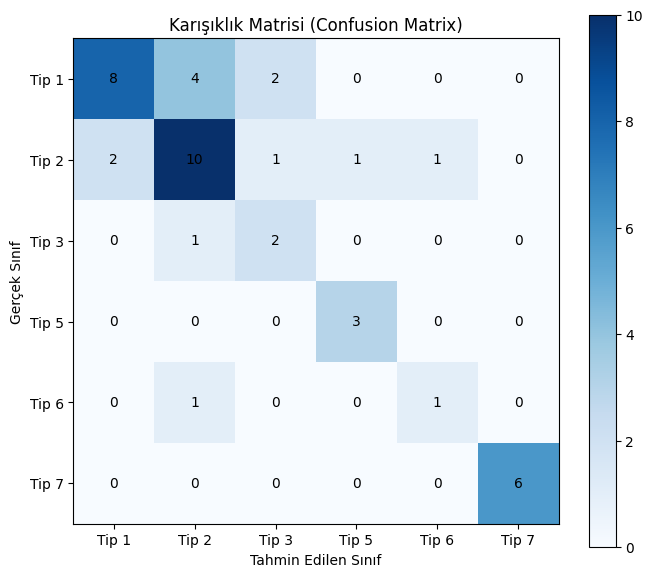

In [13]:
cm = confusion_matrix(y_test, y_pred_final, labels=sorted(y.unique()))
labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels([f"Tip {l}" for l in labels])
ax.set_yticklabels([f"Tip {l}" for l in labels])
ax.set_xlabel("Tahmin Edilen Sınıf")
ax.set_ylabel("Gerçek Sınıf")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.title("Karışıklık Matrisi (Confusion Matrix)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 10. Farklı Mesafe Ölçütlerinin Karşılaştırılması

In [14]:
metrics_to_try = ["euclidean", "manhattan", "chebyshev"]
results = {}

for metric in metrics_to_try:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    results[metric] = acc

print("Mesafe Ölçütü Karşılaştırması:")
for metric, acc in results.items():
    print(f"  {metric:<12}: {acc:.4f}")

Mesafe Ölçütü Karşılaştırması:
  euclidean   : 0.6977
  manhattan   : 0.7442
  chebyshev   : 0.6047


## 11. Örnek Tahmin

In [15]:
sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)
sample_pred = final_knn.predict(sample_scaled)[0]
sample_neighbors = final_knn.kneighbors(sample_scaled, n_neighbors=best_k)

print("Örnek cam verisi:")
display(sample)
print(f"\nTahmin edilen cam tipi: {sample_pred}")
print(f"Gerçek cam tipi: {y_test.iloc[0]}")
print(f"En yakın {best_k} komşunun mesafeleri: {np.round(sample_neighbors[0][0], 3)}")

Örnek cam verisi:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
208,1.5164,14.37,0.0,2.74,72.85,0.0,9.45,0.54,0.0



Tahmin edilen cam tipi: 7
Gerçek cam tipi: 7
En yakın 1 komşunun mesafeleri: [0.608]


## 12. Sonuç

### Önemli Kavramların Özeti
1. **KNN, tembel öğrenme (lazy learning) yapar**: Eğitim aşamasında model kurmaz, tüm veriyi saklar; tahmin anında mesafe hesabı yapar.
2. **Ölçeklendirme zorunludur**: Mesafeye dayalı bir algoritma olduğu için StandardScaler kullanılmadan yanlış sonuçlar alınabilir.
3. **k seçimi kritik bir hiperparametredir**: Çok küçük k overfitting'e, çok büyük k underfitting'e yol açar; cross-validation ile en uygun k bulunur.
4. **Küçük ve dengesiz çok sınıflı veri setlerinde** (Glass Identification gibi), az örnekli sınıflarda performans düşebilir; `classification_report` bu durumu sınıf bazında göstermeye yardımcı olur.
5. **Mesafe ölçütü** de bir hiperparametredir; Öklid dışında Manhattan gibi alternatifler de denenmelidir.

Aşağıda genel sonuç tablosu özetlenmiştir.

In [16]:
print("=== SONUÇ TABLOSU ===")
print(f"  Sıfırdan yazılan KNN (k=5) doğruluğu : {accuracy_scratch:.4f}")
print(f"  scikit-learn KNN (k=5) doğruluğu     : {accuracy_sklearn:.4f}")
print(f"  En iyi k değeri (CV ile)             : {best_k}")
print(f"  En iyi k ile test doğruluğu          : {accuracy:.4f}")

=== SONUÇ TABLOSU ===
  Sıfırdan yazılan KNN (k=5) doğruluğu : 0.6977
  scikit-learn KNN (k=5) doğruluğu     : 0.7209
  En iyi k değeri (CV ile)             : 1
  En iyi k ile test doğruluğu          : 0.6977
